In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from matplotlib.sphinxext.figmpl_directive import figmplnode
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Set plotting style for easy visibility
sns.set_theme(style = "whitegrid")

# Load the data
df = pd.read_csv("../data/raw/StudentsPerformance.csv", sep=",")

print(f"Dataset Shape: {df.shape}")
display(df.head())

Dataset Shape: (1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [7]:
# 3. Basic Info and Missing values

print("---- Dataset Information ----\n")
display(df.info())

print("--- Missing Values check ---\n")
print(df.isnull().sum().sum(), "total missing values.\n")

print("--- Summary Statistics ---\n")
print(df.describe())

df.columns

---- Dataset Information ----

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


None

--- Missing Values check ---

0 total missing values.

--- Summary Statistics ---

       math score  reading score  writing score
count  1000.00000    1000.000000    1000.000000
mean     66.08900      69.169000      68.054000
std      15.16308      14.600192      15.195657
min       0.00000      17.000000      10.000000
25%      57.00000      59.000000      57.750000
50%      66.00000      70.000000      69.000000
75%      77.00000      79.000000      79.000000
max     100.00000     100.000000     100.000000


Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

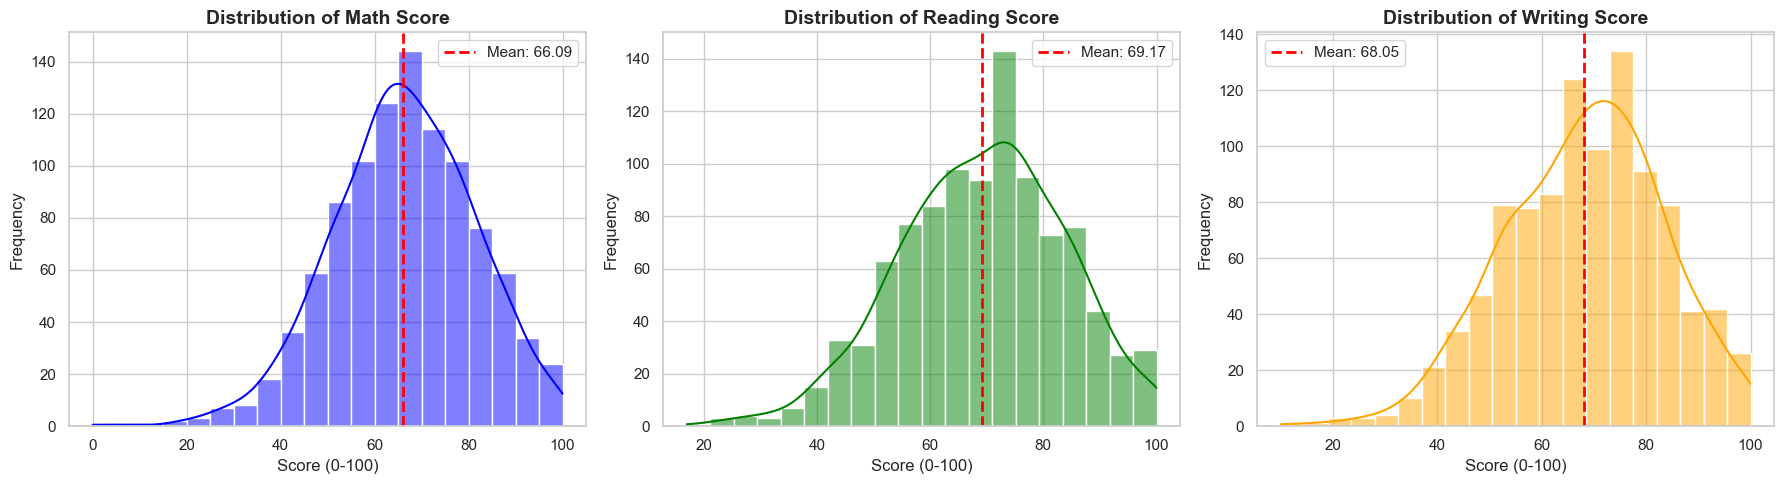

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

scores = ['math score', 'reading score', 'writing score']
colors =['blue', 'green', 'orange']

for i, col in enumerate(scores):
    sns.histplot(ax=axes[i], x=df[col], bins=20, kde=True, color=colors[i])
    axes[i].set_title(f'Distribution of {col.title()}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Score (0-100)')
    axes[i].set_ylabel('Frequency')

    # Add a vertical line for the mean
    mean_val = df[col].mean()
    axes[i].axvline(mean_val, color='red', linestyle='dashed', linewidth=2,
                    label=f'Mean: {mean_val:.2f}')
    axes[i].legend()

plt.tight_layout()
plt.show()

# Insight: All three scores are roughly normally distributed, centered around 65-69.
# No severe skewness means we don't need log transformations for our target!

C:\Users\SANJANA MUNDEWADI\AppData\Local\Temp\ipykernel_16128\4224393002.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x='gender', y='math score', data=df, palette='muted')
C:\Users\SANJANA MUNDEWADI\AppData\Local\Temp\ipykernel_16128\4224393002.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(ax=axes[1], x='test preparation course', y='math score', data=df, palette='Set2')


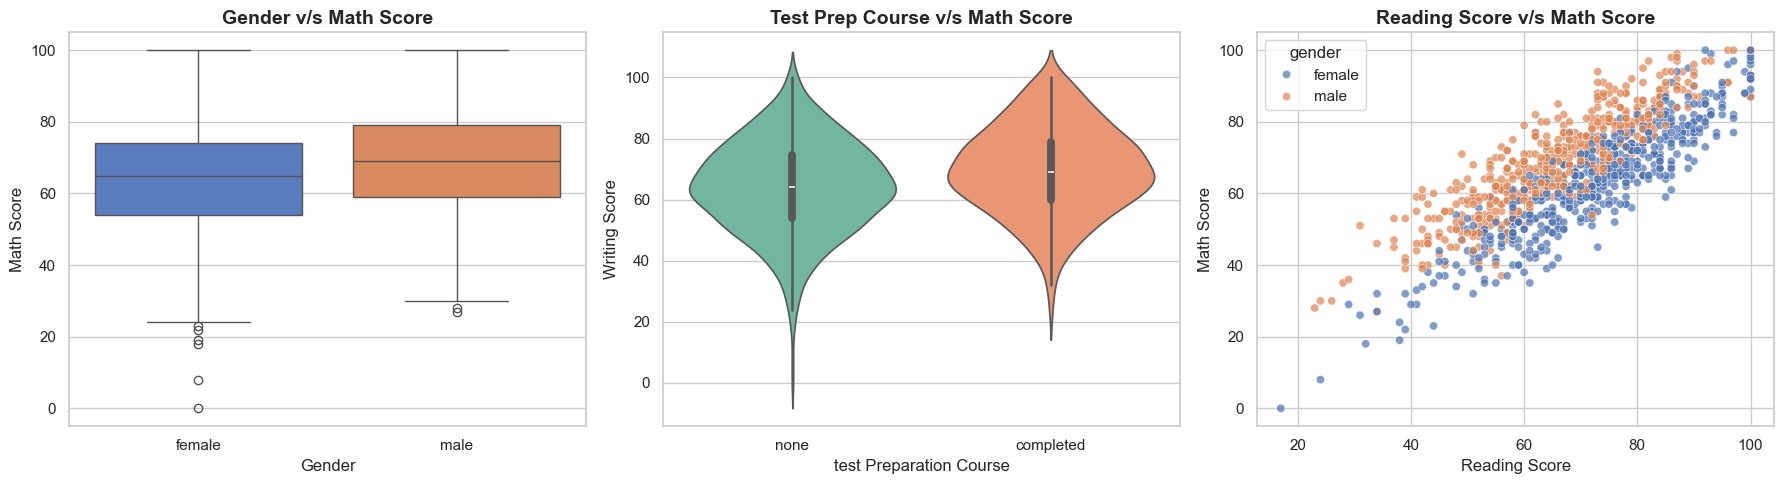

In [11]:
# Bivariate Analysis

fig, axes = plt.subplots(1, 3, figsize = (18, 5))

# 1. Gender v/s Math Score
sns.boxplot(ax=axes[0], x='gender', y='math score', data=df, palette='muted')
axes[0].set_title('Gender v/s Math Score', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Math Score')

# 2. Test Preparation Course vs Math Score (Violinplot)
sns.violinplot(ax=axes[1], x='test preparation course', y='math score', data=df, palette='Set2')
axes[1].set_title("Test Prep Course v/s Math Score", fontsize=14, fontweight='bold')
axes[1].set_xlabel("test Preparation Course")
axes[1].set_ylabel("Writing Score")

# 3. Reading Score vs Math Score (Scatterplot)
sns.scatterplot(ax=axes[2], x='reading score', y='math score', data=df, hue='gender', alpha=0.7)
axes[2].set_title('Reading Score v/s Math Score', fontsize = 14, fontweight='bold')
axes[2].set_xlabel('Reading Score')
axes[2].set_ylabel('Math Score')

plt.tight_layout()
plt.show()

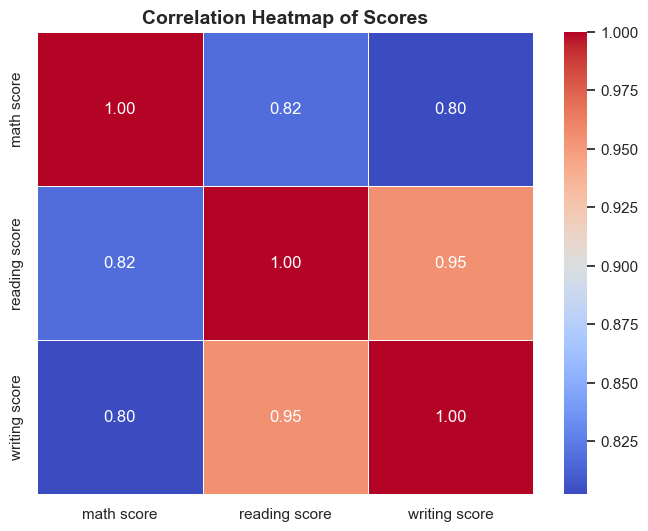

In [12]:
# Cell 5: Correlation Heatmap
plt.figure(figsize=(8, 6))

# Filter only numerical columns ('math score', 'reading score', 'writing score')
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Generate Heatmap
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Scores', fontsize=14, fontweight='bold')
plt.show()

# Insight: Reading, writing, and math scores are highly correlated (> 0.80).

In [13]:
# Data Preprocessing and train/Test Split

# Separate Features (X) and Target (y)
X = df.drop('math score', axis = 1)
y = df['math score']

# Categorical columns and Numerical Columns
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(exclude=['object']).columns

print(f"Categorical Columns: {list(cat_cols)}")
print(f"Numerical Columns: {list(num_cols)}")

# 1. Encode Categorical variables(One-Hot Encoding)
X_encoded = pd.get_dummies(X,columns= list(cat_cols), drop_first=True)

# 2. Train - Test Split (80-20)
X_train, x_test, y_train, y_test = train_test_split(X_encoded, y, test_size = 0.2, random_state = 42)

#3. Feature scaling
scaler = StandardScaler()
# Note: We fit the scaler ONLY on training data to prevent data leakage
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
x_test[num_cols] = scaler.transform(x_test[num_cols])

print(f"\nFinal X_train shape: {X_train.shape}")
print(f"Final X_test shape: {x_test.shape}")

# Re-attach target for saving
train_processed = pd.concat([X_train, y_train], axis=1)
test_processed = pd.concat([x_test, y_test], axis = 1)

# 4. Save processed data for MLflow pipeline later
train_processed.to_csv('../data/processed/train.csv', index=False)
test_processed.to_csv('../data/processed/test.csv', index=False)

print("\n✅ Phase 1 Complete: Processed data saved to 'data/processed/train.csv' and 'test.csv'")


Categorical Columns: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
Numerical Columns: ['reading score', 'writing score']

Final X_train shape: (800, 14)
Final X_test shape: (200, 14)

✅ Phase 1 Complete: Processed data saved to 'data/processed/train.csv' and 'test.csv'
